# Feature Univariate Analysis

Objective:
Understand the distribution of each feature individually.

This analysis helps detect:

- skewness
- outliers
- unusual distributions
- categorical cardinality

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

In [4]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

num_cols, cat_cols

(Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'poutcome', 'y'],
       dtype='object'))

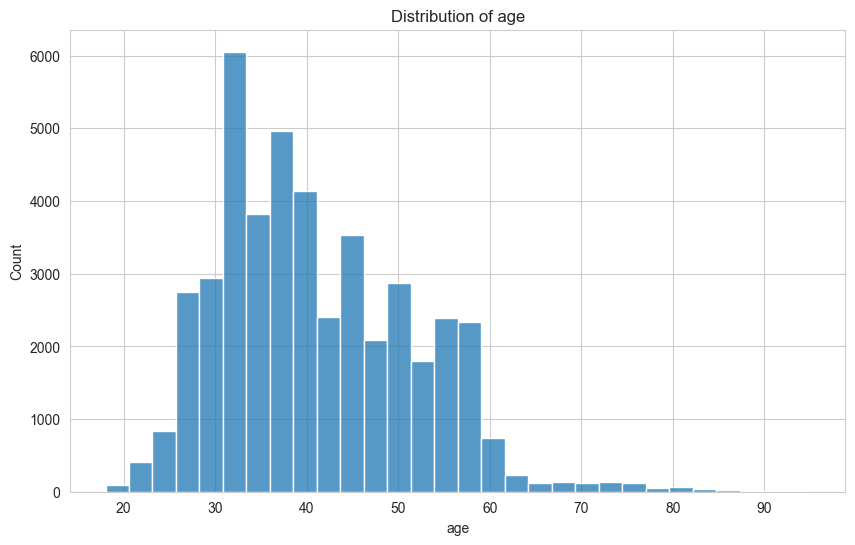

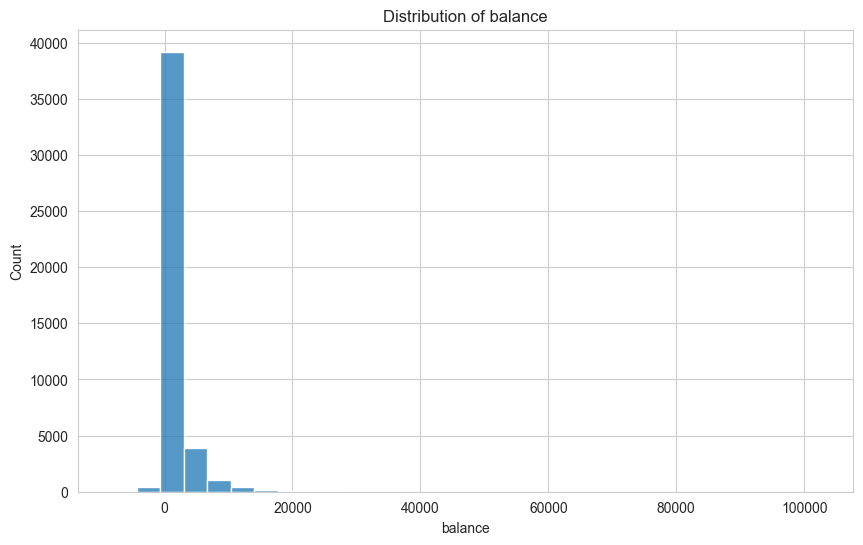

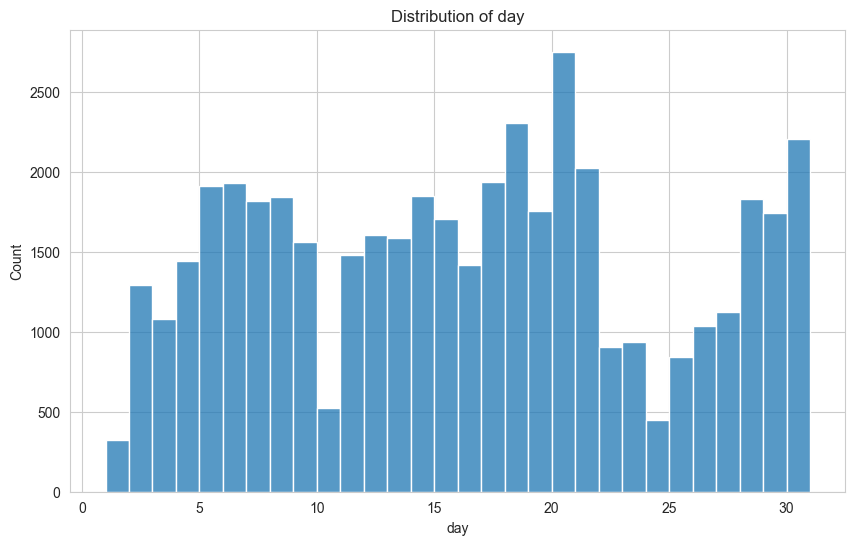

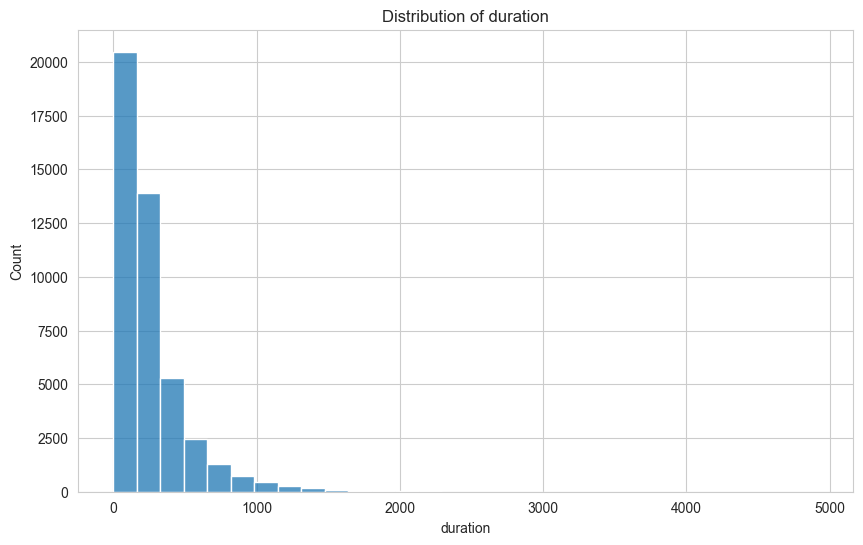

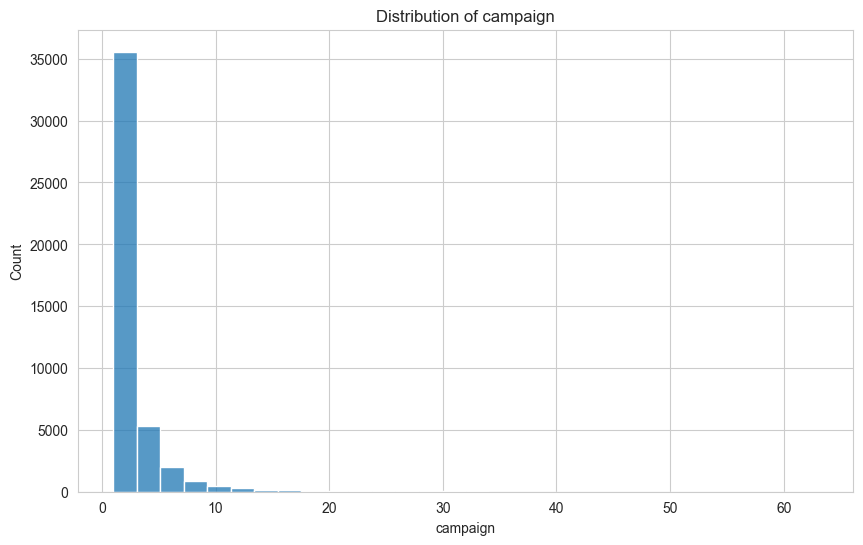

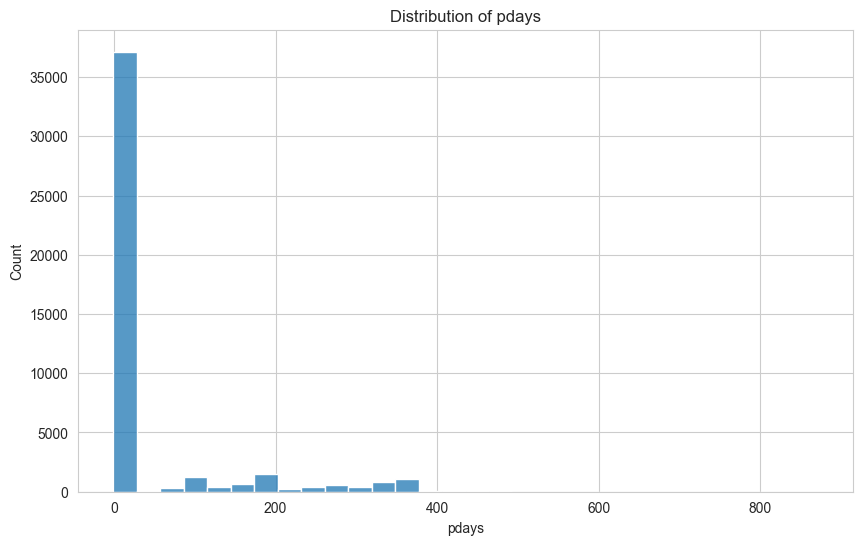

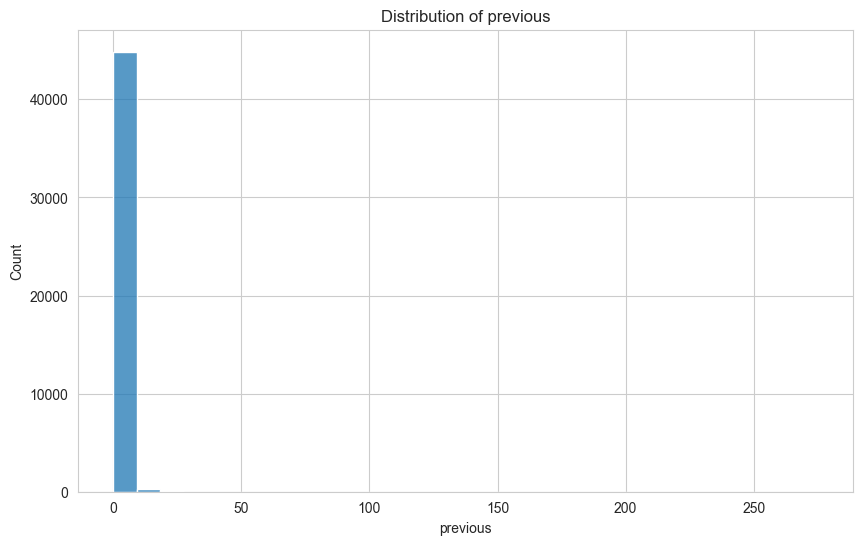

In [5]:
for col in num_cols:
    
    sns.histplot(df[col], bins=30)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

In [6]:
df[num_cols].skew().sort_values(ascending=False)

previous    41.846454
balance      8.360308
campaign     4.898650
duration     3.144318
pdays        2.615715
age          0.684818
day          0.093079
dtype: float64

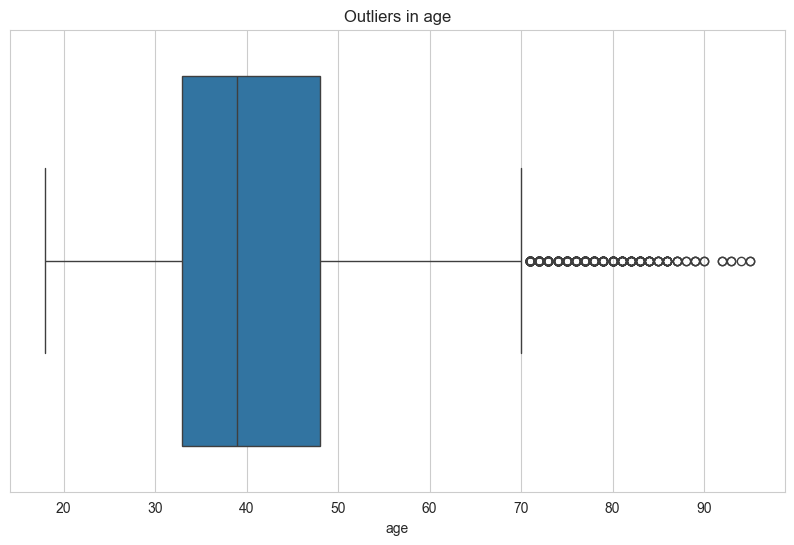

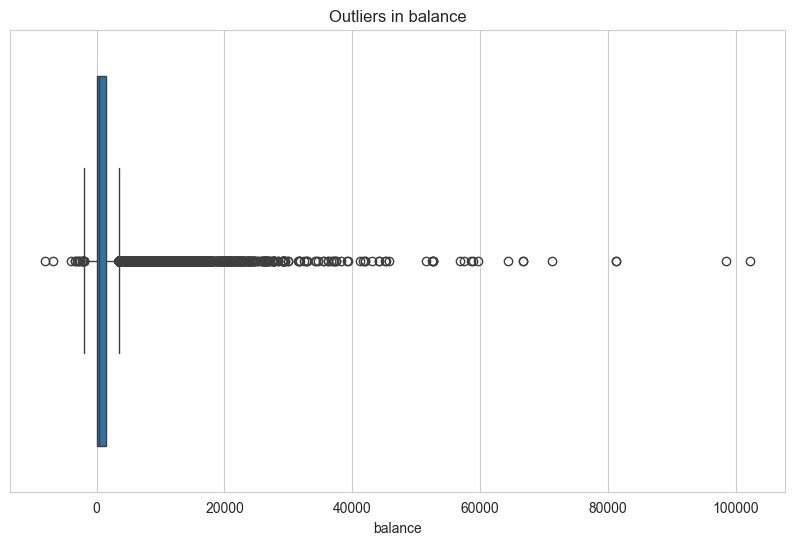

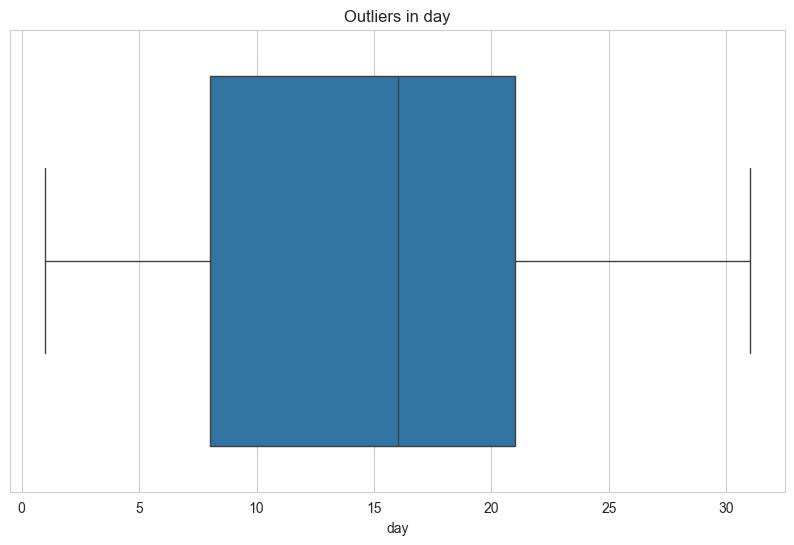

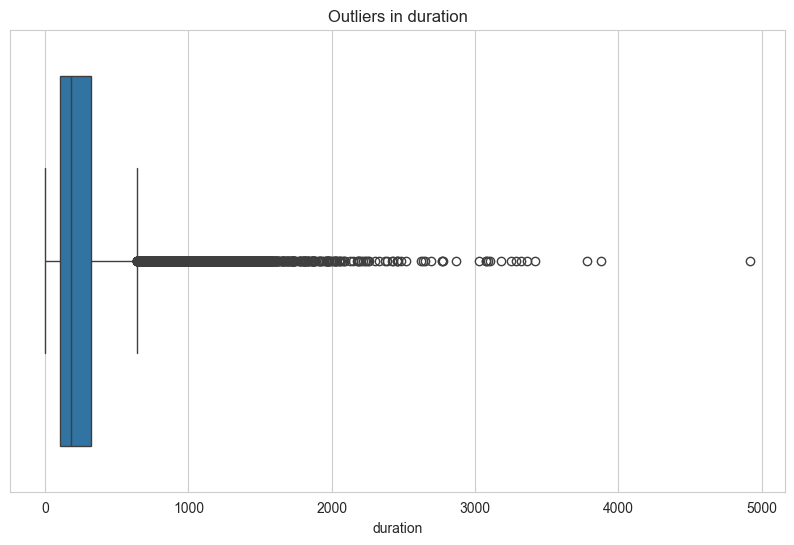

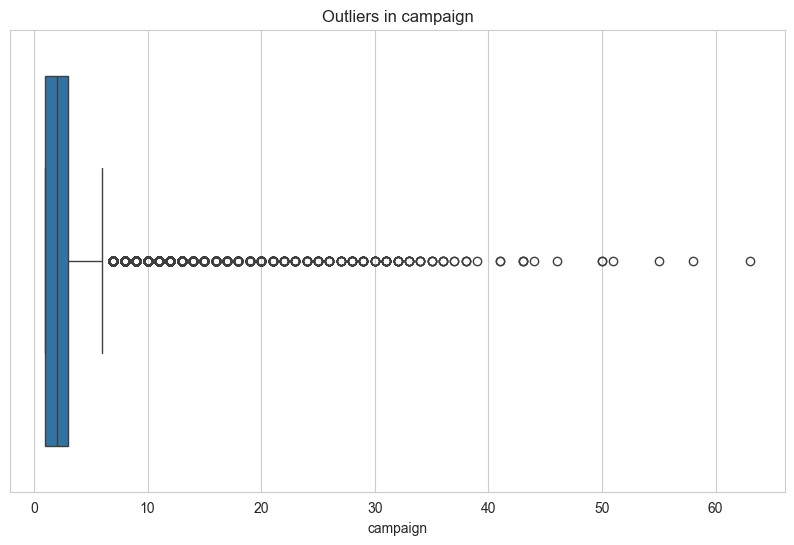

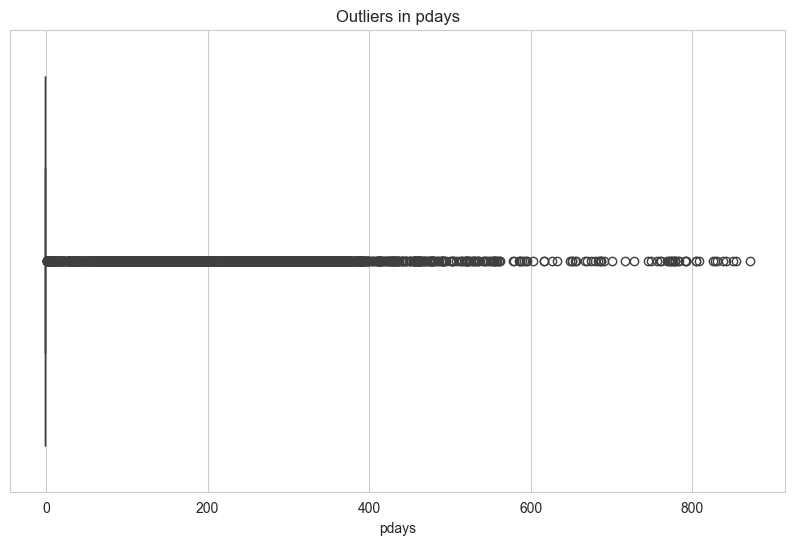

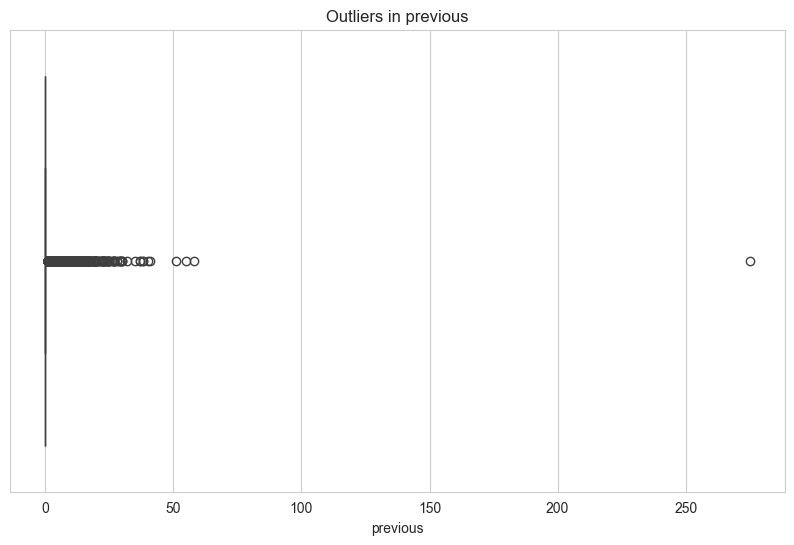

In [7]:
for col in num_cols:
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Outliers in {col}")
    
    plt.show()

In [8]:
for col in cat_cols:
    
    print(df[col].value_counts())
    print("\n")

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


default
no     44396
yes      815
Name: count, dtype: int64


housing
yes    25130
no     20081
Name: count, dtype: int64


loan
no     37967
yes     7244
Name: count, dtype: int64


contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


poutcome
unknown    36959
failure 

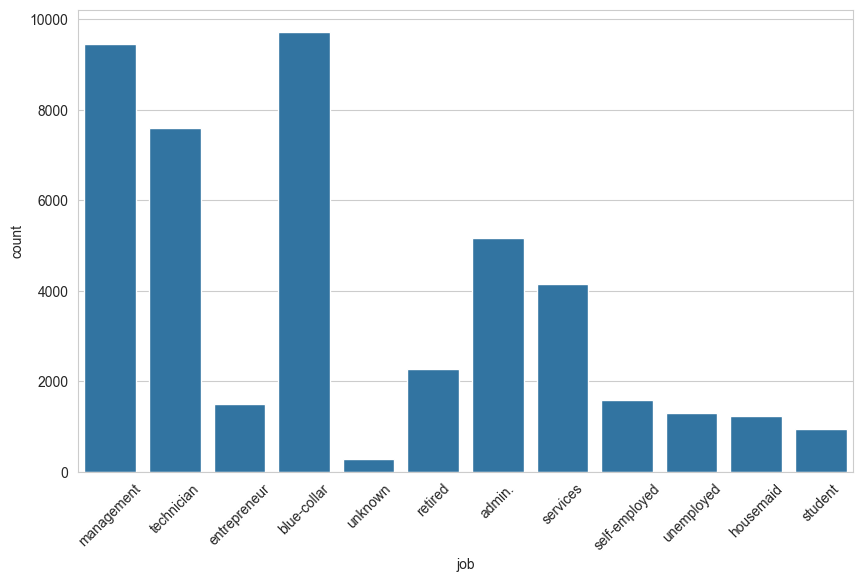

In [9]:
sns.countplot(data=df, x="job")
plt.xticks(rotation=45)
plt.show()

In [10]:
df[cat_cols].nunique().sort_values(ascending=False)

job          12
month        12
poutcome      4
education     4
marital       3
contact       3
loan          2
housing       2
default       2
y             2
dtype: int64

## Key Observations

- Several numerical variables show strong skewness (duration, campaign).
- Balance contains significant outliers.
- Categorical variables such as job and education have moderate cardinality.
- Unknown values appear in multiple categorical variables.